# Plotter Notebook

This notebook loads evaluation outputs saved under `quantized_models/analysis/` and creates
visualizations that compare quantized models vs the baseline.

It is environment-agnostic and can be run in any Conda environment that has plotting
libraries installed.

In [3]:
# # Install plotting dependencies (run once)

# import sys
# import subprocess

# REQUIRED = [
#     "pandas",
#     "numpy",
#     "matplotlib",
#     "seaborn",
# ]

# for pkg in REQUIRED:
#     try:
#         __import__(pkg)
#     except ImportError:
#         subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# print("Dependencies verified.")

In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import utils.model_loader as model_loader

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

# -----------------------------------------------------------------------------
# Load evaluation results (JSON) for the five models we want to compare
# -----------------------------------------------------------------------------

MODELS = [
    "baseline_fp16",
    "rtn_w8",
    "rtn_w4",
    "awq_w4",
    # "gptq_w4",
]

MODEL_ROOT = model_loader.OUTPUT_ROOT
EVAL_FILES = {m: MODEL_ROOT / m / "evaluation.json" for m in MODELS}

for m, p in EVAL_FILES.items():
    if not p.exists():
        raise FileNotFoundError(f"Expected evaluation JSON at {p} for model '{m}'")

records = []
for model_key, p in EVAL_FILES.items():
    with open(p, "r") as f:
        data = json.load(f)

    lm_eval = data.get("lm_eval", {}).get("results", {})

    record = {
        "model_key": model_key,
        "model_name": data.get("model_name", model_key),
        "bits": data.get("bits"),
        "total_params": data.get("total_params"),
        "weight_memory_gb": data.get("weight_memory_gb"),
        "activation_memory_mb": data.get("activation_memory_mb"),
        "perplexity": data.get("perplexity"),
        "lm_eval": lm_eval,
        "mmlu_stem": lm_eval.get("mmlu_stem", {}).get("acc,none"),
    }

    records.append(record)

results_df = pd.DataFrame(records)

ANALYSIS_DIR = model_loader.OUTPUT_ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loaded evaluation data for {len(results_df)} models")


Loaded evaluation data for 4 models


Saved plot to quantized_models_3b/analysis/size_vs_perplexity.png


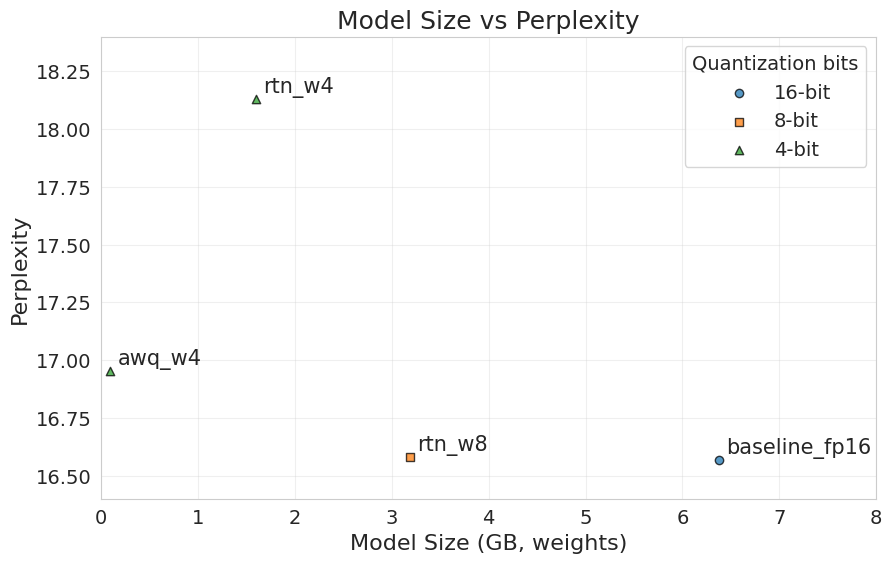

Saved plot to quantized_models_3b/analysis/task_accuracy.png


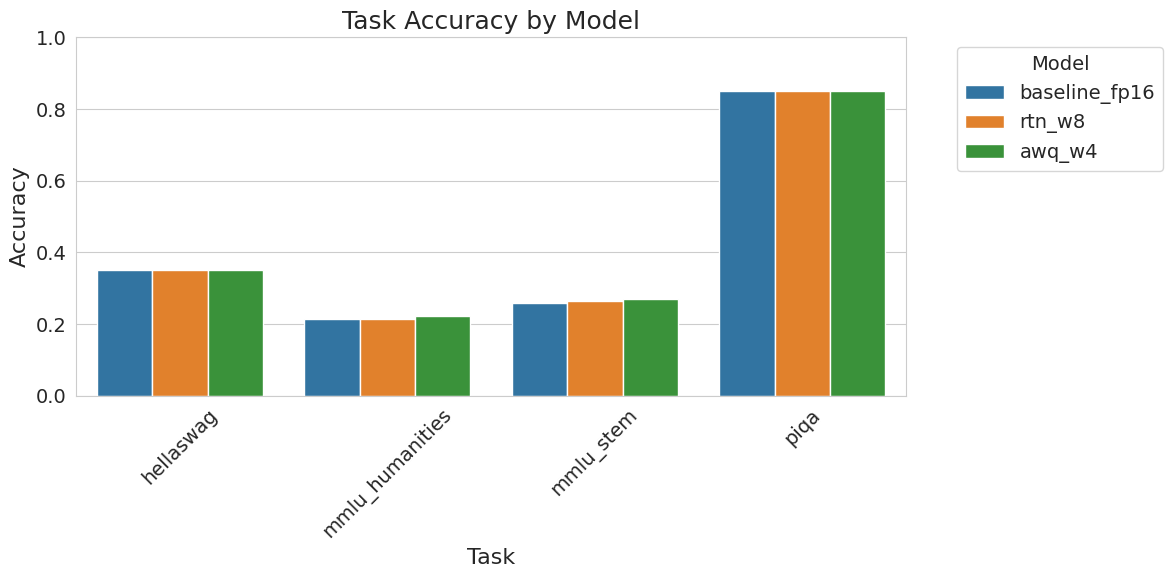

        Model  Bits Total Params  Weight Memory (GB)  Activation Memory (MB)  Perplexity  MMLU Stem
baseline_fp16    16        3.43B            6.382304                   325.0   16.567509   0.257895
       rtn_w8     8        3.43B            3.191152                   325.0   16.578598   0.263158
       rtn_w4     4        3.43B            1.595576                   325.0   18.130385   0.289474
       awq_w4     4        0.20B            0.095446                   325.0   16.952081   0.271053


In [12]:
# Plotting helpers
def plot_size_vs_perplexity(df: pd.DataFrame, output_path: Path = None):
    """Scatter plot of model size vs perplexity."""

    markers = {
        16: "o",
        8: "s",
        4: "^",
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for bits, marker in markers.items():
        subset = df[df["bits"] == bits]
        if subset.empty:
            continue

        sizes = (subset["total_params"] / 1e9) * 50
        ax.scatter(
            subset["weight_memory_gb"],
            subset["perplexity"],
            # s=sizes,
            marker=marker,
            alpha=0.75,
            edgecolor="k",
            label=f"{bits}-bit",
        )

    for _, row in df.iterrows():
        ax.annotate(
            row["model_name"],
            (row["weight_memory_gb"], row["perplexity"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=15,
        )

    ax.set_xlabel("Model Size (GB, weights)")
    ax.set_ylabel("Perplexity")
    ax.set_title("Model Size vs Perplexity")
    ax.grid(alpha=0.3)
    ax.legend(title="Quantization bits")

    ax.set_xlim(0, 8)
    ax.set_ylim(16.4, 18.4)

    # ax.text(
    #     0.98,
    #     0.02,
    #     "Dot size ∝ total params",
    #     transform=ax.transAxes,
    #     ha="right",
    #     va="bottom",
    #     fontsize=9,
    #     alpha=0.8,
    # )

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")

    plt.show()


def plot_task_accuracy(df: pd.DataFrame, output_path: Path = None):
    """Create a grouped bar plot of accuracy for each lm_eval task."""

    # Only include the quantized models for this plot (exclude baseline)
    quantized_model_keys = {"baseline_fp16", "rtn_w8", "awq_w4", "gptq_w4"}
    df = df[df["model_key"].isin(quantized_model_keys)]

    # Collect all tasks
    tasks = sorted({t for lm_eval in df["lm_eval"] for t in lm_eval.keys()})

    # Build a matrix of model x task accuracies
    acc_rows = []
    for _, row in df.iterrows():
        for task in tasks:
            task_data = row["lm_eval"].get(task, {})
            acc = task_data.get("acc,none")
            acc_rows.append(
                {
                    "model_name": row["model_name"],
                    "task": task,
                    "accuracy": acc,
                }
            )

    acc_df = pd.DataFrame(acc_rows)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=acc_df,
        x="task",
        y="accuracy",
        hue="model_name",
        ax=ax,
        palette="tab10",
    )
    ax.set_title("Task Accuracy by Model")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Task")
    ax.set_ylabel("Accuracy")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")

    plt.show()


def print_summary_table(df: pd.DataFrame):
    """Print a summary table of key model stats."""

    summary_df = df[
        [
            "model_name",
            "bits",
            "total_params",
            "weight_memory_gb",
            "activation_memory_mb",
            "perplexity",
            "mmlu_stem",
        ]
    ].copy()

    summary_df["total_params"] = summary_df["total_params"].apply(
        lambda x: f"{x/1e9:.2f}B" if x is not None else None
    )

    summary_df.columns = [
        "Model",
        "Bits",
        "Total Params",
        "Weight Memory (GB)",
        "Activation Memory (MB)",
        "Perplexity",
        "MMLU Stem",
    ]

    print(summary_df.to_string(index=False))


def plot_latency_vs_memory(df: pd.DataFrame, output_path: Path = None):
    """Scatter plot of latency vs memory usage."""

    markers = {
        16: "o",
        8: "s",
        4: "^",
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for bits, marker in markers.items():
        subset = df[df["bits"] == bits]
        if subset.empty:
            continue

        ax.scatter(
            subset["weight_memory_gb"],
            subset["avg_time_per_prompt_sec"],
            marker=marker,
            alpha=0.75,
            edgecolor="k",
            label=f"{bits}-bit",
        )

    for _, row in df.iterrows():
        ax.annotate(
            row["model_name"],
            (row["weight_memory_gb"], row["avg_time_per_prompt_sec"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=15,
        )

    ax.set_xlabel("Weight Memory (GB)")
    ax.set_ylabel("Average Latency (sec)")
    ax.set_title("Latency vs Memory Usage")
    ax.grid(alpha=0.3)
    ax.legend(title="Quantization bits")
    ax.set_xlim(0, 8)
    ax.set_ylim(0.7, 1.4)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")

    plt.show()


def plot_throughput_vs_perplexity(df: pd.DataFrame, output_path: Path = None):
    """Scatter plot of throughput vs perplexity."""

    markers = {
        16: "o",
        8: "s",
        4: "^",
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for bits, marker in markers.items():
        subset = df[df["bits"] == bits]
        if subset.empty:
            continue

        ax.scatter(
            subset["perplexity"],
            subset["throughput_tokens_per_sec"],
            marker=marker,
            alpha=0.75,
            edgecolor="k",
            label=f"{bits}-bit",
        )

    # Define offsets to avoid overlapping labels
    label_offsets = {
        # "baseline_fp16": (5, 5),
        "rtn_w8": (5, 15),
        "rtn_w4": (5, -5),
        # "awq_w4": (-5, -5),
        "gptq_w4": (0, 10),
    }

    for _, row in df.iterrows():
        offset = label_offsets.get(row["model_name"], (5, 5))
        ax.annotate(
            row["model_name"],
            (row["perplexity"], row["throughput_tokens_per_sec"]),
            xytext=offset,
            textcoords="offset points",
            fontsize=15,
        )

    ax.set_xlabel("Perplexity")
    ax.set_ylabel("Throughput (tokens/sec)")
    ax.set_title("Throughput vs Perplexity")
    ax.grid(alpha=0.3)
    ax.legend(title="Quantization bits")
    ax.set_xlim(16.2, 18.4)
    ax.set_ylim(100, 200)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")

    plt.show()


# Generate plots + table
plot_size_vs_perplexity(results_df, output_path=ANALYSIS_DIR / "size_vs_perplexity.png")
plot_task_accuracy(results_df, output_path=ANALYSIS_DIR / "task_accuracy.png")
print_summary_table(results_df)

In [13]:
# -----------------------------------------------------------------------------
# Load inference speed results (JSON) for latency/throughput analysis
# -----------------------------------------------------------------------------

INFERENCE_FILES = {m: MODEL_ROOT / m / "inference_speed.json" for m in MODELS}

inference_records = []
for model_key, p in INFERENCE_FILES.items():
    if not p.exists():
        print(f"Warning: Inference speed file not found for {model_key}: {p}")
        continue
    with open(p, "r") as f:
        data = json.load(f)

    record = {
        "model_key": model_key,
        "avg_time_per_prompt_sec": data.get("avg_time_per_prompt_sec"),
        "throughput_tokens_per_sec": data.get("throughput_tokens_per_sec"),
    }

    inference_records.append(record)

inference_df = pd.DataFrame(inference_records)

# Add inference metrics to results_df
if not inference_df.empty and "avg_time_per_prompt_sec" not in results_df.columns:
    results_df = results_df.merge(inference_df, on="model_key", how="left")

print(f"Loaded inference speed data for {len(inference_df)} models")
print(f"Updated results_df with inference metrics")

Loaded inference speed data for 4 models
Updated results_df with inference metrics


In [14]:
def print_inference_summary_table(df: pd.DataFrame):
    """Print a summary table of inference stats."""

    cols = ["model_name", "bits", "weight_memory_gb"]
    col_names = ["Model", "Bits", "Weight Memory (GB)"]
    if "avg_time_per_prompt_sec" in df.columns:
        cols.append("avg_time_per_prompt_sec")
        col_names.append("Avg Latency (sec)")
    if "throughput_tokens_per_sec" in df.columns:
        cols.append("throughput_tokens_per_sec")
        col_names.append("Throughput (tokens/sec)")

    summary_df = df[cols].copy()
    summary_df.columns = col_names

    print(summary_df.to_string(index=False))

Saved plot to quantized_models_3b/analysis/latency_vs_memory.png


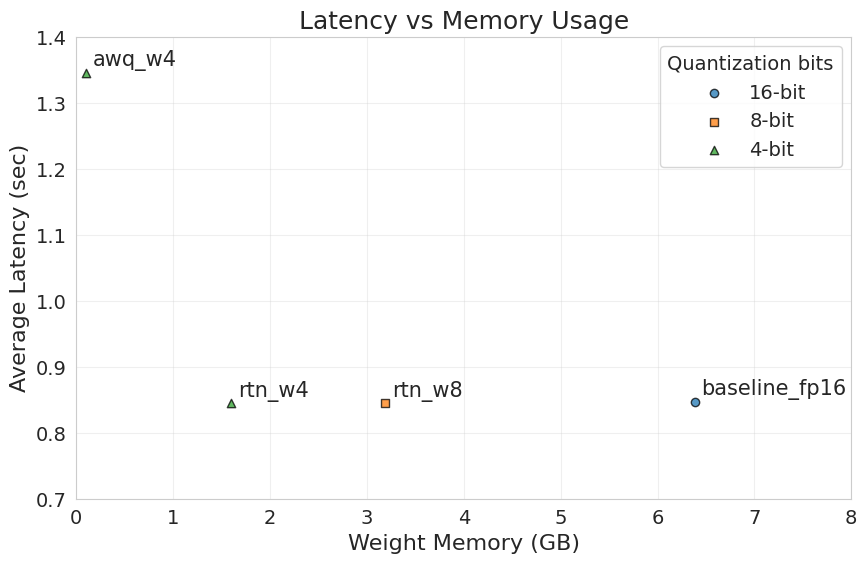

Saved plot to quantized_models_3b/analysis/throughput_vs_perplexity.png


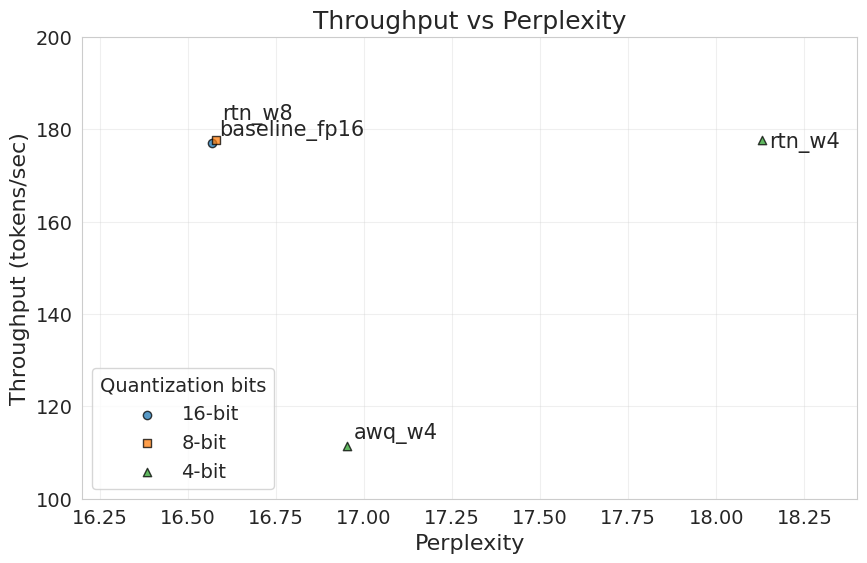

        Model  Bits  Weight Memory (GB)  Avg Latency (sec)  Throughput (tokens/sec)
baseline_fp16    16            6.382304           0.847007               177.094162
       rtn_w8     8            3.191152           0.844543               177.610942
       rtn_w4     4            1.595576           0.844757               177.565838
       awq_w4     4            0.095446           1.345615               111.473231


In [15]:
# Generate inference speed plots + table
if "avg_time_per_prompt_sec" in results_df.columns:
    plot_latency_vs_memory(results_df, output_path=ANALYSIS_DIR / "latency_vs_memory.png")
    plot_throughput_vs_perplexity(results_df, output_path=ANALYSIS_DIR / "throughput_vs_perplexity.png")
    print_inference_summary_table(results_df)
else:
    print("No inference speed data available for plotting.")

In [16]:
results_df.columns

Index(['model_key', 'model_name', 'bits', 'total_params', 'weight_memory_gb',
       'activation_memory_mb', 'perplexity', 'lm_eval', 'mmlu_stem',
       'avg_time_per_prompt_sec', 'throughput_tokens_per_sec'],
      dtype='object')

In [17]:
inference_df.columns

Index(['model_key', 'avg_time_per_prompt_sec', 'throughput_tokens_per_sec'], dtype='object')

In [18]:
# Clean up duplicate columns from multiple merges
if 'avg_time_per_prompt_sec_x' in results_df.columns:
    results_df = results_df.drop(columns=['avg_time_per_prompt_sec_y', 'throughput_tokens_per_sec_y'])
    results_df = results_df.rename(columns={'avg_time_per_prompt_sec_x': 'avg_time_per_prompt_sec', 'throughput_tokens_per_sec_x': 'throughput_tokens_per_sec'})

print("Cleaned results_df columns:")
print(results_df.columns.tolist())

Cleaned results_df columns:
['model_key', 'model_name', 'bits', 'total_params', 'weight_memory_gb', 'activation_memory_mb', 'perplexity', 'lm_eval', 'mmlu_stem', 'avg_time_per_prompt_sec', 'throughput_tokens_per_sec']
